In [2]:
import dill
import numpy as np

protocol_times=np.linspace(200,2000,10)
protocol_times_lower=np.linspace(400,4000,10)

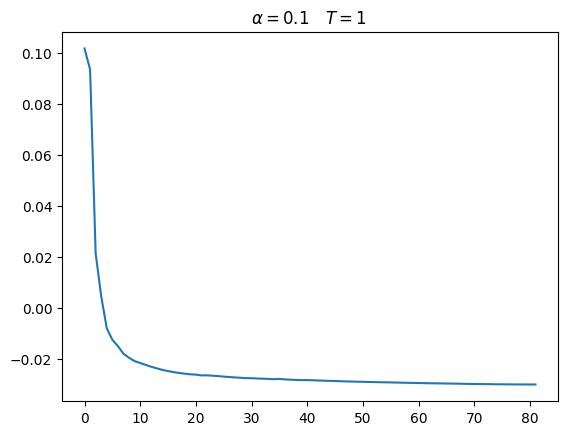

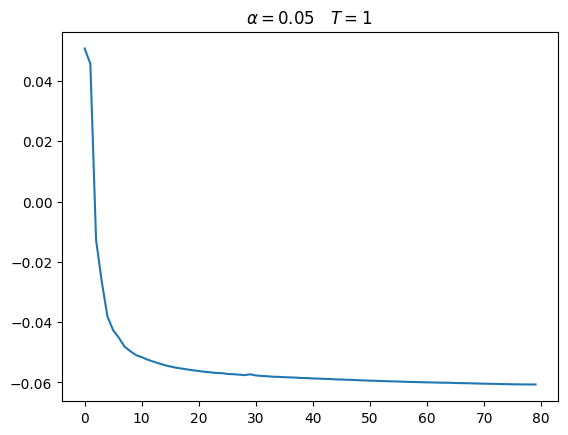

In [21]:
import matplotlib.pyplot as plt

final_heats_a1_T1=[]
final_heats_a5_T1=[]

final_heats_a1_T10=[]
final_heats_a5_T10=[]


""" 
for t_prot in protocol_times:
    with open(f'/Users/eoinoneill/Desktop/OQuPy/results/zero_control/conv_checks/dt=0.1_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/{t_prot:.0f}ps', 'rb') as f:
        opt_prot = dill.load(f)
        print(opt_prot.keys())
        final_heats.append(opt_prot["result"].fun)
        opt_time.append(opt_prot["opttime"])
plt.plot(protocol_times,final_heats,'bo-')
"""
for t_prot in protocol_times:
    with open(f'/Users/eoinoneill/Desktop/OQuPy/results/zero_control/conv_checks/dt=0.2_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/{t_prot:.0f}ps', 'rb') as f:
        lind_heats_a1_T1 = dill.load(f)
        final_heats_a1_T1.append(lind_heats_a1_T1["result"].fun)

num_its=np.shape(lind_heats_a1_T1['log'])[0]
fin_heats=[entry['full heats'][-1] for entry in lind_heats_a1_T1['log']]
plt.plot(fin_heats)
plt.title(r"$\alpha=0.1 \quad T=1$ ")
plt.show()

for t_prot in protocol_times:
    with open(f'/Users/eoinoneill/Desktop/OQuPy/results/convergence_checks/a=0.1_T=10/dt=0.1_ps=-8.0_tcut=500_x=3.5/{t_prot:.0f}ps', 'rb') as f:
        opt_prot_a1_T10 = dill.load(f)
        #final_heats_a5_T10.append(opt_prot_a5_T10["result"].fun)
        final_heats_a1_T10.append(opt_prot_a1_T10["heats"][-1])

for t_prot in protocol_times_lower:
    with open(f'/Users/eoinoneill/Desktop/OQuPy/results/zero_control_lower_coupling/conv_checks/dt=0.25_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/{t_prot:.0f}ps', 'rb') as f:
        opt_prot_a5_T1 = dill.load(f)
        final_heats_a5_T1.append(opt_prot_a5_T1["result"].fun)

num_its=np.shape(opt_prot_a5_T1['log'])[0]
fin_heats=[entry['full heats'][-1] for entry in opt_prot_a5_T1['log']]
plt.plot(fin_heats)
plt.title(r"$\alpha=0.05 \quad T=1$ ")
plt.show()

for t_prot in protocol_times_lower:
    
    with open(f'/Users/eoinoneill/Desktop/OQuPy/results/convergence_checks/a=0.05_T=10/dt=0.1_ps=-8.0_tcut=500_x=3.5/{t_prot:.0f}ps', 'rb') as f:
        opt_prot_a5_T10 = dill.load(f)
        final_heats_a5_T10.append(opt_prot_a5_T10["heats"][-1])


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


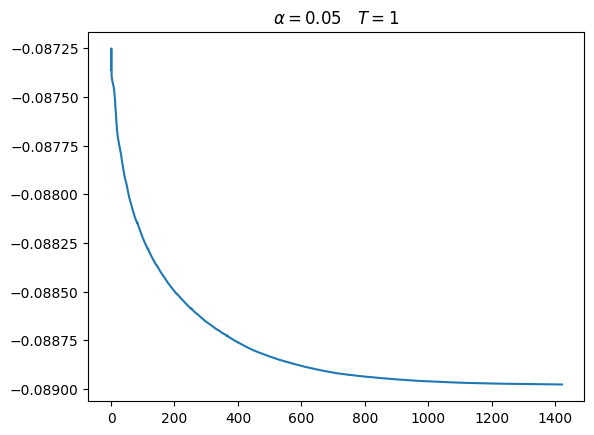

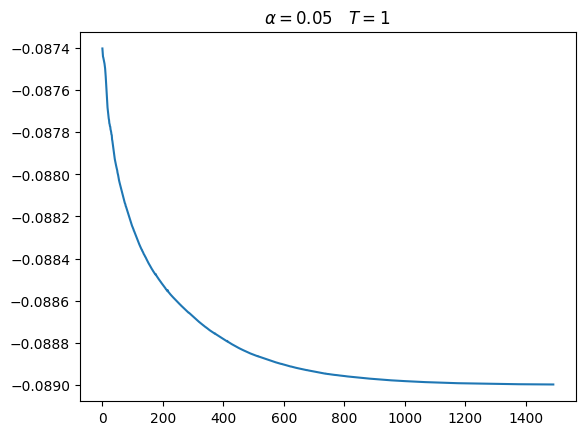

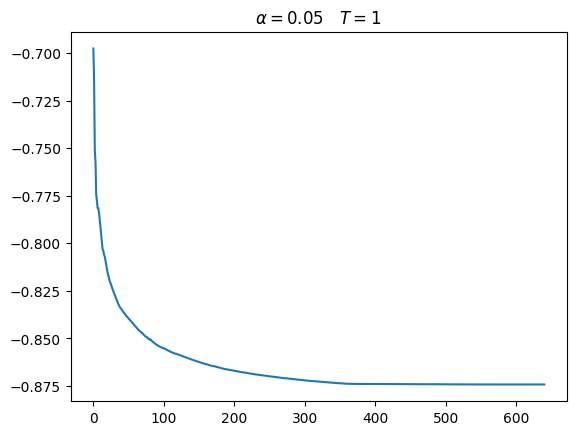

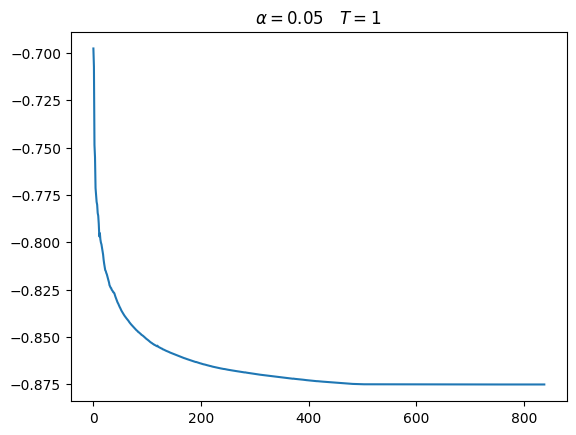

In [4]:
import matplotlib.pyplot as plt

lind_opts={(0.1,1):{},(0.05,1):{},(0.1,10):{},(0.05,10):{}}
alphas=[0.1,0.05]
temps=[1,10]

for temp in temps:
    for alpha in alphas:
        prot_times=np.linspace(int(20/alpha),int(200/alpha),10)
        for t_prot in prot_times:
            with open(f'results/lindblad_control/a={alpha},T={temp}/dt=5.0/{t_prot:.0f}ps', 'rb') as f:
                lind_opts[(alpha,temp)][t_prot] = dill.load(f)

        dict_temp=lind_opts[(alpha,temp)][prot_times[-1]]
        num_its=np.shape(dict_temp["optlog"])[0]
        fin_heats=[entry for entry in dict_temp["optlog"]]
        plt.plot(fin_heats)
        plt.title(r"$\alpha=0.05 \quad T=1$ ")
        plt.show()

In [41]:
lind_heats_a1_T1=[lind_opts[(0.1,1)][t]["result"].fun/0.131 for t in protocol_times]
lind_heats_a5_T1=[lind_opts[(0.05,1)][t]["result"].fun/0.131 for t in protocol_times_lower]

lind_heats_a1_T10=[lind_opts[(0.1,10)][t]["result"].fun/1.31 for t in protocol_times]
lind_heats_a5_T10=[lind_opts[(0.05,10)][t]["result"].fun/1.31 for t in protocol_times_lower]

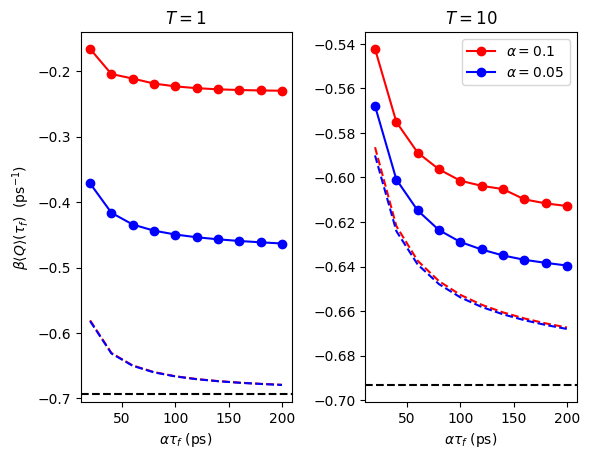

(-5.1848393923873894-4.50743436166613e-12j)
(-0.5094329029882819-4.428576020979361e-13j)


In [39]:
fig,axs=plt.subplots(1,2)

norm_final_heats_a5_T1=[q/0.131 for q in final_heats_a5_T1]
norm_final_heats_a1_T1=[q/0.131 for q in final_heats_a1_T1]

norm_final_heats_a5_T10=[q/1.31 for q in final_heats_a5_T10]
norm_final_heats_a1_T10=[q/1.31 for q in final_heats_a1_T10]

axs[0].plot(0.1*protocol_times,norm_final_heats_a1_T1,'ro-',label=r"$\alpha=0.1$")
axs[0].plot(0.05*protocol_times_lower,norm_final_heats_a5_T1,'bo-',label=r"$\alpha=0.05$")
axs[0].plot(0.1*protocol_times,lind_heats_a1_T1,'r--')
axs[0].plot(0.05*protocol_times_lower,lind_heats_a5_T1,'b--')
axs[0].axhline(-np.log(2),linestyle='dashed',color='black')
axs[0].set_title(r"$T=1$")
axs[0].set_xlabel(r"$\alpha \tau_{f} $ (ps)")
axs[0].set_ylabel(r"$\beta \langle Q \rangle  (\tau_f) $  $(\text{ps}^{-1})$")

#axs[1].plot(0.1*protocol_times,final_heats_a1_T10,'ro-',label=r"$\alpha=0.1$")
#axs[1].plot(0.05*protocol_times_lower,final_heats_a5_T10,'bo-',label=r"$\alpha=0.05$")
axs[1].plot(0.1*protocol_times,norm_final_heats_a1_T10,'ro-',label=r"$\alpha=0.1$")
axs[1].plot(0.05*protocol_times_lower,norm_final_heats_a5_T10,'bo-',label=r"$\alpha=0.05$")
axs[1].plot(0.1*protocol_times,lind_heats_a1_T10,'r--')
axs[1].plot(0.05*protocol_times_lower,lind_heats_a5_T10,'b--')
axs[1].axhline(-np.log(2),linestyle='dashed',color='black')
axs[1].set_title(r"$T=10$")
axs[1].set_xlabel(r"$\alpha \tau_{f} $ (ps)")
plt.subplots_adjust(wspace=0.35)
plt.legend()
plt.show()
# should we normalise the heat aswell?
print(lind_heats_a1_T1[-1]/0.131)
print(lind_heats_a1_T10[-1]/1.31)

/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


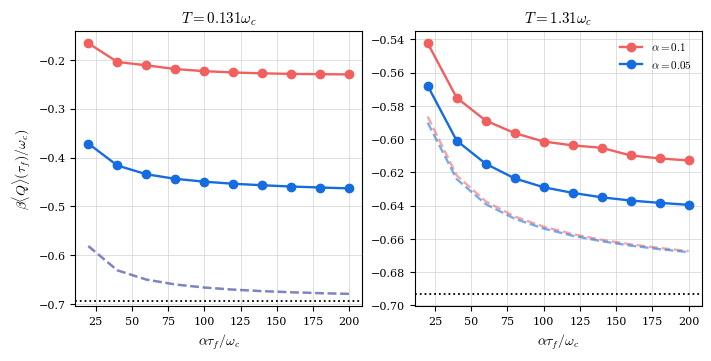

(-5.1848393923873894-4.50743436166613e-12j)
(-0.5094329029882819-4.428576020979361e-13j)


In [53]:
import matplotlib.pyplot as plt
import numpy as np

# --- Style parameters ---
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.7,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

# softer colors and corresponding pale versions for dotted lines
colors = {"a5": "#146ce0", "a1": "#f25f5f"}
pale_colors = {"a1": "#e0821466", "a5": "#4dac2666"}  # hex + alpha for transparency

fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), constrained_layout=True)

# normalize heats
norm_final_heats_a5_T1 = [q/0.131 for q in final_heats_a5_T1]
norm_final_heats_a1_T1 = [q/0.131 for q in final_heats_a1_T1]
norm_final_heats_a5_T10 = [q/1.31 for q in final_heats_a5_T10]
norm_final_heats_a1_T10 = [q/1.31 for q in final_heats_a1_T10]

pale_off="90"

# --- T=1 panel ---
axs[0].plot(0.1*protocol_times, norm_final_heats_a1_T1, 'o-', color=colors["a1"], label=r"$\alpha=0.1$")
axs[0].plot(0.05*protocol_times_lower, norm_final_heats_a5_T1, 'o-', color=colors["a5"], label=r"$\alpha=0.05$")
axs[0].plot(0.1*protocol_times, lind_heats_a1_T1, '--', color=colors["a1"]+pale_off)
axs[0].plot(0.05*protocol_times_lower, lind_heats_a5_T1, '--', color=colors["a5"]+pale_off)
axs[0].axhline(-np.log(2), linestyle=":", color="black", linewidth=1.3)

axs[0].set_title(r"$T=0.131 \omega_c$")
axs[0].set_xlabel(r"$\alpha \tau_{f} / \omega_c$")
axs[0].set_ylabel(r"$\beta \langle Q \rangle (\tau_f) / \omega_c)$")

# --- T=10 panel ---
axs[1].plot(0.1*protocol_times, norm_final_heats_a1_T10, 'o-', color=colors["a1"], label=r"$\alpha=0.1$")
axs[1].plot(0.05*protocol_times_lower, norm_final_heats_a5_T10, 'o-', color=colors["a5"], label=r"$\alpha=0.05$")
axs[1].plot(0.1*protocol_times, lind_heats_a1_T10, '--', color=colors["a1"]+pale_off)
axs[1].plot(0.05*protocol_times_lower, lind_heats_a5_T10, '--', color=colors["a5"]+pale_off)
axs[1].axhline(-np.log(2), linestyle=":", color="black", linewidth=1.3)

axs[1].set_title(r"$T=1.31 \omega_c$")
axs[1].set_xlabel(r"$\alpha \tau_{f} / \omega_c$")

# --- General styling ---
for ax in axs:
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

axs[1].legend(frameon=False)
plt.savefig('Q_v_prottime.eps', format='eps')
plt.show()

# check normalization
print(lind_heats_a1_T1[-1]/0.131)
print(lind_heats_a1_T10[-1]/1.31)

In [ ]:
import oqupy,dill
from scipy.interpolate import interp1d

# interpolating control
# returns interpolated control function for given input time step and finer time step
def interpolate_control(opt_control, t_total, dt_control,dt_finer):

    hx = opt_control

    t_L = np.arange(len(hx)) * dt_control

    # TEMPO simulation times
    t_T = np.arange(int(t_total/dt_finer)+1) * dt_finer

    h_t = interp1d(
        t_L,
        hx,
        kind="cubic",     
        bounds_error=False,
        fill_value=(hx[0], hx[-1])
    )
    return h_t
"""
plt.step(t_L, hx, where="post", label="rough params")
plt.plot(t_T, h_t(t_T), alpha=0.6, label="finer params")
plt.legend()
plt.show()
"""

'\nplt.step(t_L, hx, where="post", label="rough params")\nplt.plot(t_T, h_t(t_T), alpha=0.6, label="finer params")\nplt.legend()\nplt.show()\n'

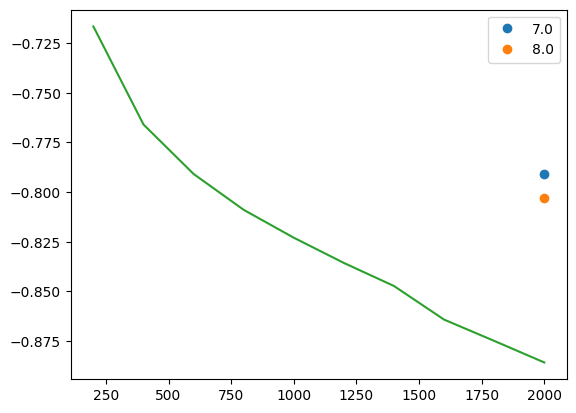

In [42]:
from oqupy.system import TimeDependentSystem
import oqupy.operators as op

# dt=0.1 change eps
for epsrel in [7.0,8.0]:
    final_Qs=[]
    for t_prot in [2000]:
        with open(f'results/convergence_checks/a=0.1_T=10/dt=0.1_ps=-{epsrel}_tcut=500_x=3.5/{t_prot}ps', 'rb') as f:
            conv_dict = dill.load(f)
        final_Qs.append(conv_dict["heats"][-1])


    plt.plot([2000],final_Qs,'o',label=epsrel)
plt.plot(protocol_times,final_heats_a1_T10)
plt.legend()
plt.show()


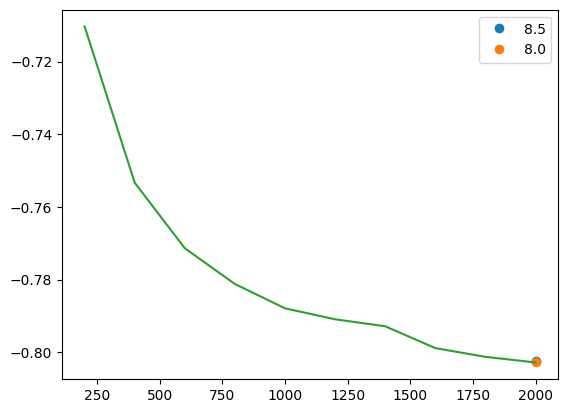

In [35]:
from oqupy.system import TimeDependentSystem
import oqupy.operators as op

# dt=0.1 change eps
for epsrel in [8.5,8.0]:
    final_Qs=[]
    for t_prot in [2000]:
        with open(f'results/convergence_checks/a=0.1_T=10/dt=0.1_ps=-{epsrel}_tcut=1000_x=3.5/{t_prot}ps', 'rb') as f:
            conv_dict = dill.load(f)
        final_Qs.append(conv_dict["heats"][-1])


    plt.plot([2000],final_Qs,'o',label=epsrel)
plt.plot(protocol_times,final_heats_a1_T10)
plt.legend()
plt.show()


[-0.8027766764675769]
[-0.8027766764674463]
[-0.8027766764674463]


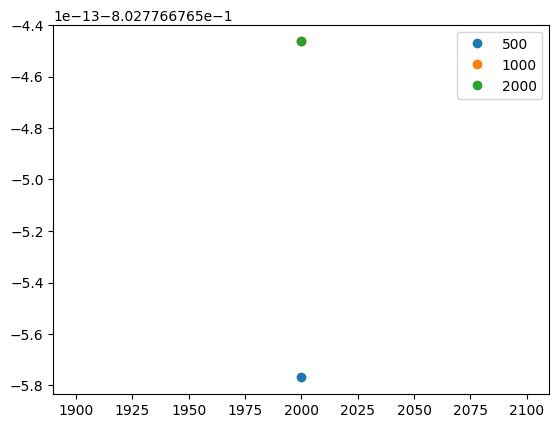

In [31]:

for tcut in [500,1000,2000]:
    final_Qs=[]
    for t_prot in [2000]:
        with open(f'results/convergence_checks/a=0.1_T=10/dt=0.1_ps=-8.0_tcut={tcut}_x=3.5/{t_prot}ps', 'rb') as f:
            conv_dict = dill.load(f)
        final_Qs.append(conv_dict["heats"][-1])

        plt.plot([2000],final_Qs,'o',label=tcut)
    print(final_Qs)
plt.legend()
plt.show()

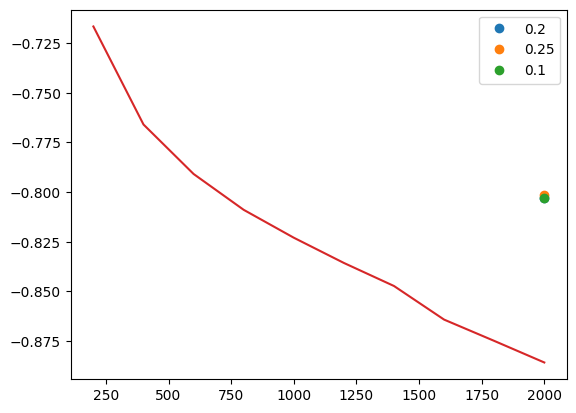

In [55]:
from oqupy.system import TimeDependentSystem
import oqupy.operators as op


for dt in [0.2,0.25]:
    final_Qs=[]
    for t_prot in [2000]:
        with open(f'results/convergence_checks/a=0.1_T=10/dt={dt}_ps=-8.0_tcut=1000_x=3.5/{t_prot}ps', 'rb') as f:
            conv_dict = dill.load(f)
        final_Qs.append(conv_dict["heats"][-1])

        plt.plot([2000],final_Qs,'o',label=dt)


final_Qs=[]
with open(f'results/convergence_checks/a=0.1_T=10/dt=0.1_ps=-8.0_tcut=500_x=3.5/{2000}ps', 'rb') as f:
    conv_dict = dill.load(f)
final_Qs.append(conv_dict["heats"][-1])

plt.plot([2000],final_Qs,'o',label=0.1)


plt.plot(protocol_times,final_heats_a1_T10)
plt.legend()
plt.show()


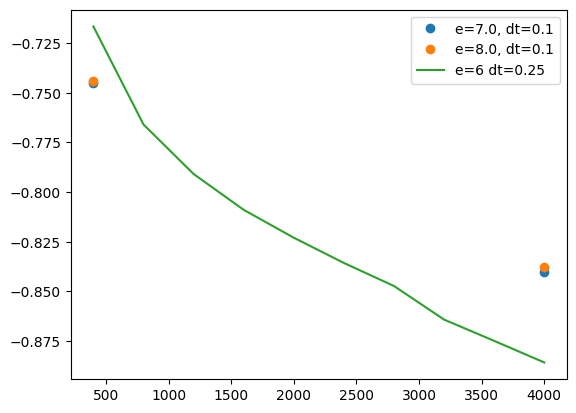

In [ ]:
from oqupy.system import TimeDependentSystem
import oqupy.operators as op


for epsrel in [7.0,8.0]:
    final_Qs=[]
    for t_prot in [400,4000]:
        with open(f'results/convergence_checks/a=0.05_T=10/dt=0.1_ps=-{epsrel}_tcut=500_x=3.5/{t_prot}ps', 'rb') as f:
            conv_dict = dill.load(f)
        final_Qs.append(conv_dict["heats"][-1])


    plt.plot([400,4000],final_Qs,'o',label="e={0}, dt=0.1".format(epsrel))
    
plt.plot(protocol_times_lower,final_heats_a1_T10, label="e=8 dt=0.1")

plt.legend()
plt.show()


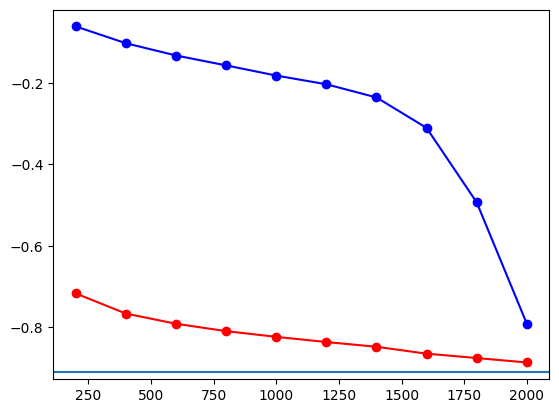

In [58]:
plt.plot(protocol_times,last_heats,'bo-')
plt.plot(protocol_times,final_heats_a1_T10,'ro-')
plt.axhline(-0.131*np.log(2)*10)

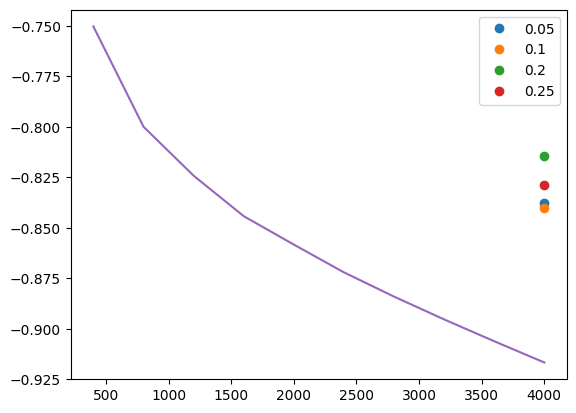

In [23]:
from oqupy.system import TimeDependentSystem
import oqupy.operators as op


for dt in [0.05,0.1,0.2,0.25]:
    final_Qs=[]
    for t_prot in [4000]:
        with open(f'results/convergence_checks/a=0.05_T=10/dt={dt}_ps=-7.0_tcut=500_x=3.5/{t_prot}ps', 'rb') as f:
            conv_dict = dill.load(f)
        final_Qs.append(conv_dict["heats"][-1])


    plt.plot([4000],final_Qs,'o',label=dt)
plt.plot(protocol_times_lower,final_heats_a5_T10)
plt.legend()
plt.show()
